# MIDL quick demo for math problem

Build `D_in` -> compute `basis` -> construct dimensionless `Pi` -> run `MIDL.fit` -> recover exponents.

In [1]:
import numpy as np
import midl
from midl import MIDL


In [6]:
# Synthetic data
rng = np.random.default_rng(123)
n_samples = 1000

x = rng.uniform(0.1, 3.24, n_samples)
y = rng.uniform(0.1, 3.24, n_samples)
z = rng.uniform(0.1, 3.24, n_samples)
L = rng.uniform(0.9, 1.1, n_samples)

X_raw = np.column_stack([x, y, z, L])
u = np.sin(x*y/L/L) * np.cos(z/L)
# Dimension matrix D_in (shape: (l, m))
D_in = np.matrix([1, 1, 1, 1])
print("Dimension matrix D_in:\n", D_in)

# Compute basis vectors (π exponents) and rank
basis, r = midl.calc_basis(D_in)
print("Null space dimension:", D_in.shape[1] - r)
print("basis shape:", basis.shape)
print("basis (π exponents):\n", basis)

# Transform X_raw to dimensionless inputs Pi
Pi = np.zeros((X_raw.shape[0], basis.shape[1]))

for i in range(X_raw.shape[0]):
    log_x = np.log(X_raw[i, :])
    Pi[i, :] = np.exp(log_x @ basis)
#print("Pi shape:", Pi.shape)


Dimension matrix D_in:
 [[1 1 1 1]]
Null space dimension: 3
basis shape: (4, 3)
basis (π exponents):
 [[-0.5        -0.5        -0.5       ]
 [ 0.83333333 -0.16666667 -0.16666667]
 [-0.16666667  0.83333333 -0.16666667]
 [-0.16666667 -0.16666667  0.83333333]]


In [7]:
# Run MIDL
model = MIDL(
    k_neighbors=6,
    de_maxiter=200,
    random_state=42,
)

result = model.fit(Pi_independent=Pi, pi_dependent=u,threshold=5)
pi_hat = MIDL.compose_new_pi(Pi, result["W"])

print("\n=== MIDL Results ===")
print("MI scores:", result["mi_scores"])
#print("W (columns are w_i):")
#print(result["W"])
print("dominant_q:", result["dominant_q"])
print("drop ratios I_i / I_(i+1):", result["drop_ratios"])

# Recover exponents in the original variable space
alpha = basis @ result["W"]
print("\n=== Recovered exponents ===")
print(alpha)


[Step 1] MI = 0.727213
[Step 2] MI = 0.537989
   ratio = 1.352
[Step 3] MI = 0.000000
   ratio = 537988737123.841
   >>> Early stopping triggered at step 3

=== MIDL Results ===
MI scores: [0.72721323 0.53798874]
dominant_q: 2
drop ratios I_i / I_(i+1): 537988737123.84143

=== Recovered exponents ===
[[ 0.00301569 -0.49370861]
 [ 0.00363317 -0.50623006]
 [ 0.70376665  0.50467334]
 [-0.71041552  0.49526533]]


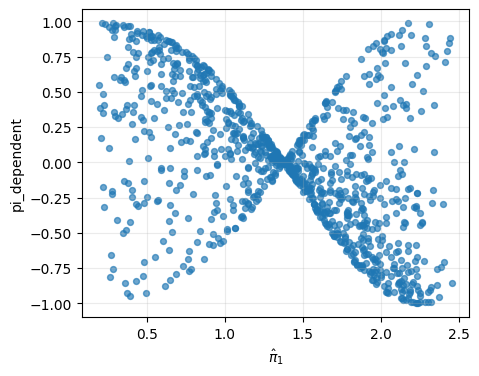

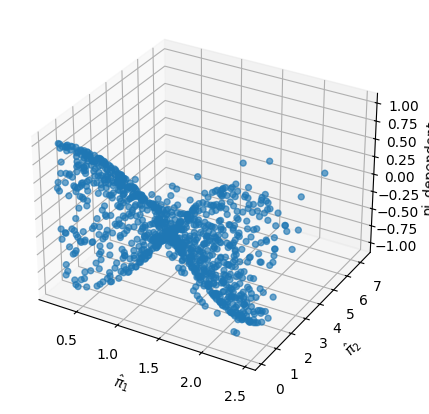

In [8]:
if result["dominant_q"] >= 2:
    ax2d, ax3d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=u,
        W=result["W"],
        dominant_q=result["dominant_q"],
        component_index=0,
    )
else:
    ax2d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=u,
        W=result["W"],
        dominant_q=result["dominant_q"],
        component_index=0,
    )